# 数据读取

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
df = pd.read_csv("D:/VsCodeProjects/Ecommerce_User_Analysis/data/cleaned_data.csv")

In [30]:
df.head()

,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour,weekday
0,128078,4630672,2033408,pv,1512266009,2017-12-03 09:53:29,2017-12-03,9,Sunday
1,10035,3667432,1080785,pv,1511890180,2017-11-29 01:29:40,2017-11-29,1,Wednesday
2,109218,2403812,3430419,pv,1512232651,2017-12-03 00:37:31,2017-12-03,0,Sunday
3,106205,5150006,1165503,pv,1511855219,2017-11-28 15:46:59,2017-11-28,15,Tuesday
4,1002307,905583,2520377,pv,1511795200,2017-11-27 23:06:40,2017-11-27,23,Monday


# 用户行为分布分析


In [31]:
behavior_count = df["behavior_type"].value_counts()
print(behavior_count)

behavior_type
pv      1794141
cart     110316
fav       58098
buy       40461
Name: count, dtype: int64


In [32]:
behavior_ratio = (behavior_count / behavior_count.sum() * 100).round(2)
print(behavior_ratio)

behavior_type
pv      89.57
cart     5.51
fav      2.90
buy      2.02
Name: count, dtype: float64


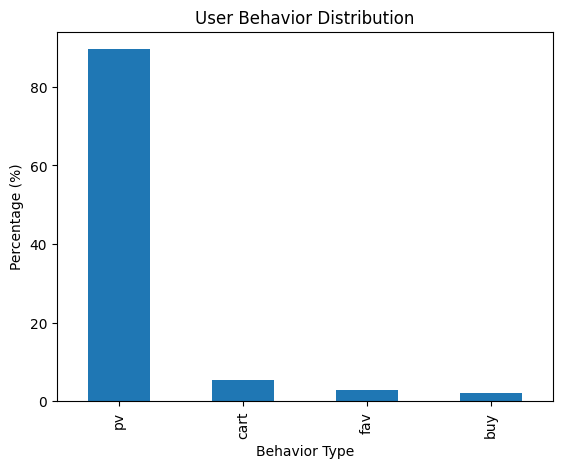

In [33]:
behavior_ratio.plot(kind="bar")

plt.title("User Behavior Distribution")
plt.xlabel("Behavior Type")
plt.ylabel("Percentage (%)")

plt.savefig(r'D:\VsCodeProjects\Ecommerce_User_Analysis\figures\User_Behavior_Distribution.png',dpi=300,bbox_inches='tight')
plt.show()

# 用户活跃时间分析


In [34]:
hour_count = df.groupby("hour").size()
hour_count

hour
0      68075
1      31590
2      17112
3      11695
4      10009
5      12838
6      26933
7      49571
8      67992
9      84102
10     97811
11     94870
12     95749
13    104318
14    103699
15    107601
16    103918
17     93856
18     95455
19    120266
20    146144
21    167658
22    165789
23    125965
dtype: int64

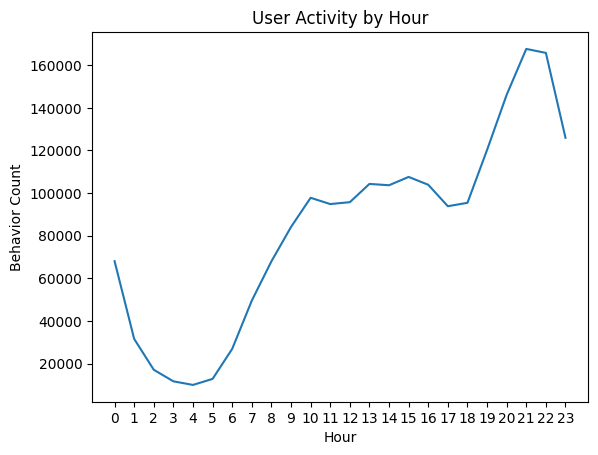

In [35]:
hour_count.plot(kind="line")
plt.title("User Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Behavior Count")

plt.xticks(range(24))
plt.savefig(r'D:\VsCodeProjects\Ecommerce_User_Analysis\figures\User_Activity_by_Hour.png',dpi=300,bbox_inches='tight')
plt.show()

# 星期维度行为分析


In [36]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
weekday_count = df["weekday"].value_counts().reindex(weekday_order)
print(weekday_count)

weekday
Monday       201672
Tuesday      197872
Wednesday    206654
Thursday     209038
Friday       217842
Saturday     483148
Sunday       486790
Name: count, dtype: int64


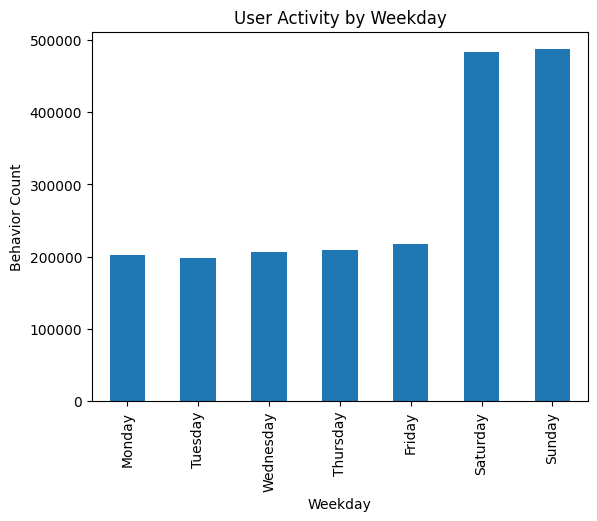

In [37]:
weekday_count.plot(kind="bar")
plt.title("User Activity by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Behavior Count")
plt.savefig(r'D:\VsCodeProjects\Ecommerce_User_Analysis\figures\User_Activity_by_Weekday.png',dpi=300,bbox_inches='tight')

plt.show()

# 热门商品分析

In [38]:
top_item = df["item_id"].value_counts().head(10)
print(top_item)

item_id
812879     634
3845720    564
138964     458
2331370    450
2032668    430
3031354    403
2818406    369
3371523    365
1591862    365
2338453    364
Name: count, dtype: int64


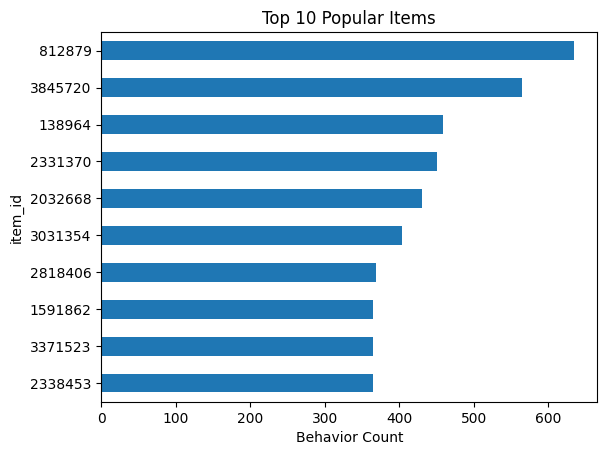

In [39]:
top_item.sort_values().plot(kind="barh")

plt.title("Top 10 Popular Items")
plt.xlabel("Behavior Count")
plt.savefig(r'D:\VsCodeProjects\Ecommerce_User_Analysis\figures\Top_10_Popular_Items.png',dpi=300,bbox_inches='tight')

plt.show()

# 热门品类分析

In [40]:
top_category = df["category_id"].value_counts().head(10)
print(top_category)

category_id
4756105    97152
4145813    69280
2355072    67491
3607361    63382
982926     61530
2520377    43643
4801426    41878
1320293    39457
2465336    33195
3002561    31169
Name: count, dtype: int64


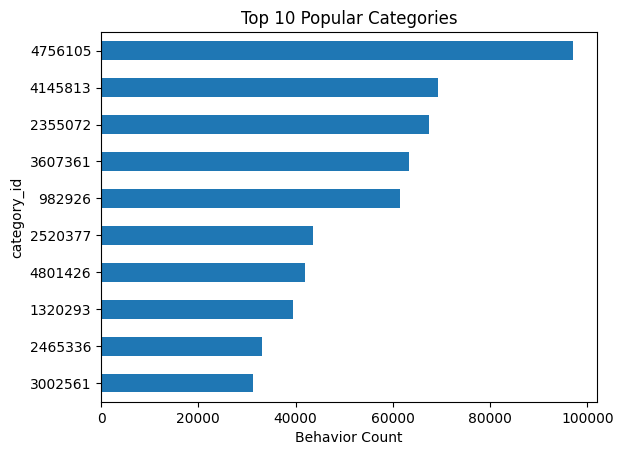

In [41]:
top_category.sort_values().plot(kind="barh")
plt.title("Top 10 Popular Categories")
plt.xlabel("Behavior Count")
plt.savefig(r'D:\VsCodeProjects\Ecommerce_User_Analysis\figures\Top_10_Popular_Categories.png',dpi=300,bbox_inches='tight')

plt.show()

# 本章结论

## 用户行为分析结论

1. 用户行为以浏览为主，购买行为占比较低，存在较大的转化提升空间。

2. 用户活跃度呈现明显的时间规律，中午、下午时段为行为高峰期。

3. 不同星期的用户行为存在一定差异，可据此优化运营活动安排。

4. 商品与品类热度呈现头部集中趋势，高热度商品和品类具有较高的运营价值。